# Exploratory Data Analysis

In [7]:
# Standard library imports
import os
import json

# Data manipulation and visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Image processing
from PIL import Image
import cv2
import matplotlib.image as mpimg  # For loading images

In [8]:
def create_dummy_image():
    dummy_image_path = "nosample.png" 
    if os.path.exists(dummy_image_path):
        return mpimg.imread(dummy_image_path)
    else:
        print(f"Warning: '{dummy_image_path}' not found. Using a blank dummy image.")
        return np.ones((100, 100, 3), dtype=np.uint8) * 255

In [9]:
# Define the directory containing the labeled dataset
directory = r'C:\Users\david\Desktop\project\dataset\Labeled'

# Initialize an empty list to store data
data = []

# Iterate through all files in the directory
for file in os.listdir(directory):
    if file.lower().endswith('.jpg'):
        image_path = os.path.join(directory, file)
        json_path = image_path.replace('.jpg', '.json')
        
        label = None
        if os.path.exists(json_path):
            try:
                with open(json_path, 'r') as f:
                    content = json.load(f)
                    shapes = content.get('shapes', [])
                    if shapes and isinstance(shapes, list):
                        label = shapes[0].get('label')
            except Exception as e:
                print(f"Error reading {json_path}: {e}")
        
        data.append({'filename': image_path, 'label': label})

df = pd.DataFrame(data)
print(df.info())
display(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 428 entries, 0 to 427
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   filename  428 non-null    object
 1   label     428 non-null    object
dtypes: object(2)
memory usage: 6.8+ KB
None


,filename,label
0,C:\Users\david\Desktop\project\dataset\Labeled...,no_good
1,C:\Users\david\Desktop\project\dataset\Labeled...,no_good
2,C:\Users\david\Desktop\project\dataset\Labeled...,no_good
3,C:\Users\david\Desktop\project\dataset\Labeled...,no_good
4,C:\Users\david\Desktop\project\dataset\Labeled...,good


# EDA

In [10]:
df.label.value_counts()

label
good           162
no_good        116
exc_solder      81
spike           38
poor_solder     31
Name: count, dtype: int64

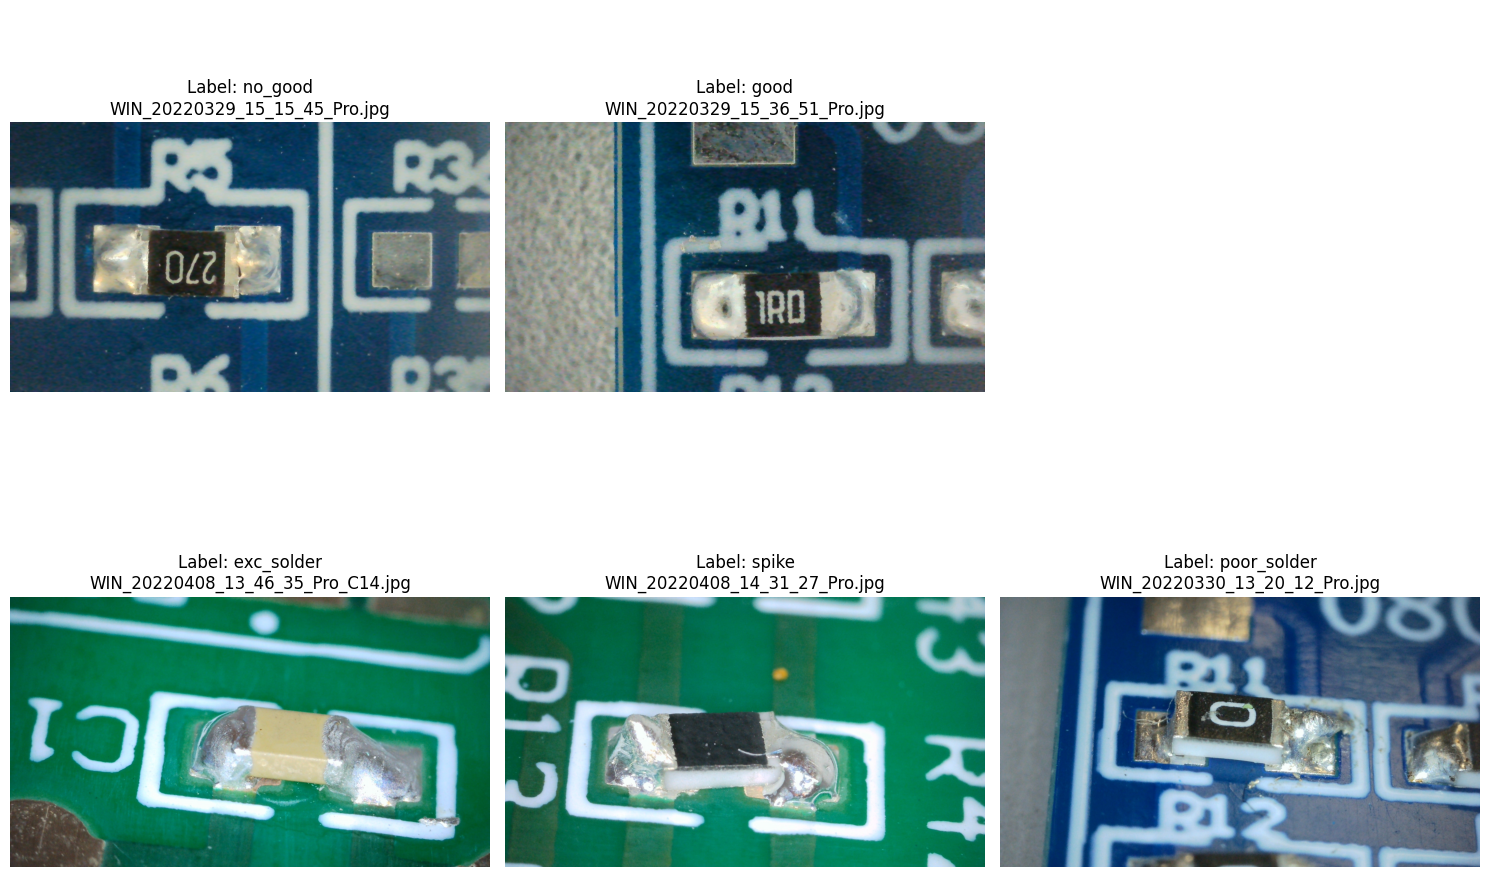

In [11]:
# Define subplot mapping for labels
subplot_mapping = {
    "no_good": (0, 0),
    "good": (0, 1),
    "exc_solder": (1, 0),
    "spike": (1, 1),
    "poor_solder": (1, 2)
}

# Create a 2x3 grid of subplots
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Iterate through each label and its subplot position
for label, (row, col) in subplot_mapping.items():
    ax = axes[row, col]
    group = df[df['label'] == label]
    
    if not group.empty:
        # Sample one image from the group
        sample = group.sample(n=1).iloc[0]
        image_path = sample['filename']
        
        try:
            # Load and display the image
            image = Image.open(image_path)
            ax.imshow(image)
        except Exception as e:
            # Display error message if image loading fails
            ax.text(0.5, 0.5, f"Error loading image:\n{e}", ha='center', va='center')
    else:
        # Display message if no image is found for the label
        ax.text(0.5, 0.5, "No image found", ha='center', va='center')
    
    # Set title and turn off axis
    ax.set_title(f"Label: {label}\n{os.path.basename(sample['filename']) if not group.empty else ''}")
    ax.axis('off')

# Turn off unused subplot axes if there are fewer than 6 unique labels
used_positions = set(subplot_mapping.values())
for r in range(2):
    for c in range(3):
        if (r, c) not in used_positions:
            axes[r, c].axis('off')

# Adjust layout and display the plot
plt.tight_layout()
plt.show()

# preprocessing and augmentation

In [12]:
# Preprocessing
df_filtered = df[~df['label'].isin(['good', 'no_good'])].copy()

In [39]:
def extract_roi(image_path, json_path):
    """
    Extracts a region of interest (ROI) that includes the entire component and both solder joints.
    Ensures the component is centered and fully visible with adequate padding.
    """
    try:
        # Read the image
        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        with open(json_path, 'r') as f:
            content = json.load(f)
            shapes = content.get('shapes', [])
            
            if shapes and isinstance(shapes, list):
                # Get all points from all shapes
                all_points = []
                for shape in shapes:
                    points = shape.get('points', [])
                    if points:
                        all_points.extend(points)
                
                if all_points:
                    # Convert points to numpy array
                    points = np.array(all_points, dtype=np.int32)
                    
                    # Get bounding box
                    x, y, w, h = cv2.boundingRect(points)
                    
                    # Calculate center
                    center_x = x + w // 2
                    center_y = y + h // 2
                    
                    # Make ROI wider to ensure both solder joints are visible
                    # Width is 3x the component width or height (whichever is larger)
                    size_w = max(w, h) * 3
                    # Height is 2x the component height
                    size_h = h * 2
                    
                    # Calculate crop coordinates with padding
                    x1 = max(0, center_x - size_w // 2)
                    y1 = max(0, center_y - size_h // 2)
                    x2 = min(image.shape[1], x1 + size_w)
                    y2 = min(image.shape[0], y1 + size_h)
                    
                    # Adjust coordinates if they hit image boundaries
                    if x1 == 0:
                        x2 = min(image.shape[1], size_w)
                    if y1 == 0:
                        y2 = min(image.shape[0], size_h)
                    if x2 == image.shape[1]:
                        x1 = max(0, x2 - size_w)
                    if y2 == image.shape[0]:
                        y1 = max(0, y2 - size_h)
                    
                    # Extract ROI
                    roi = image[y1:y2, x1:x2]
                    return roi
                    
            print(f"No valid shapes found in {json_path}")
            return image
            
    except Exception as e:
        print(f"Error extracting ROI from {image_path}: {e}")
        return image

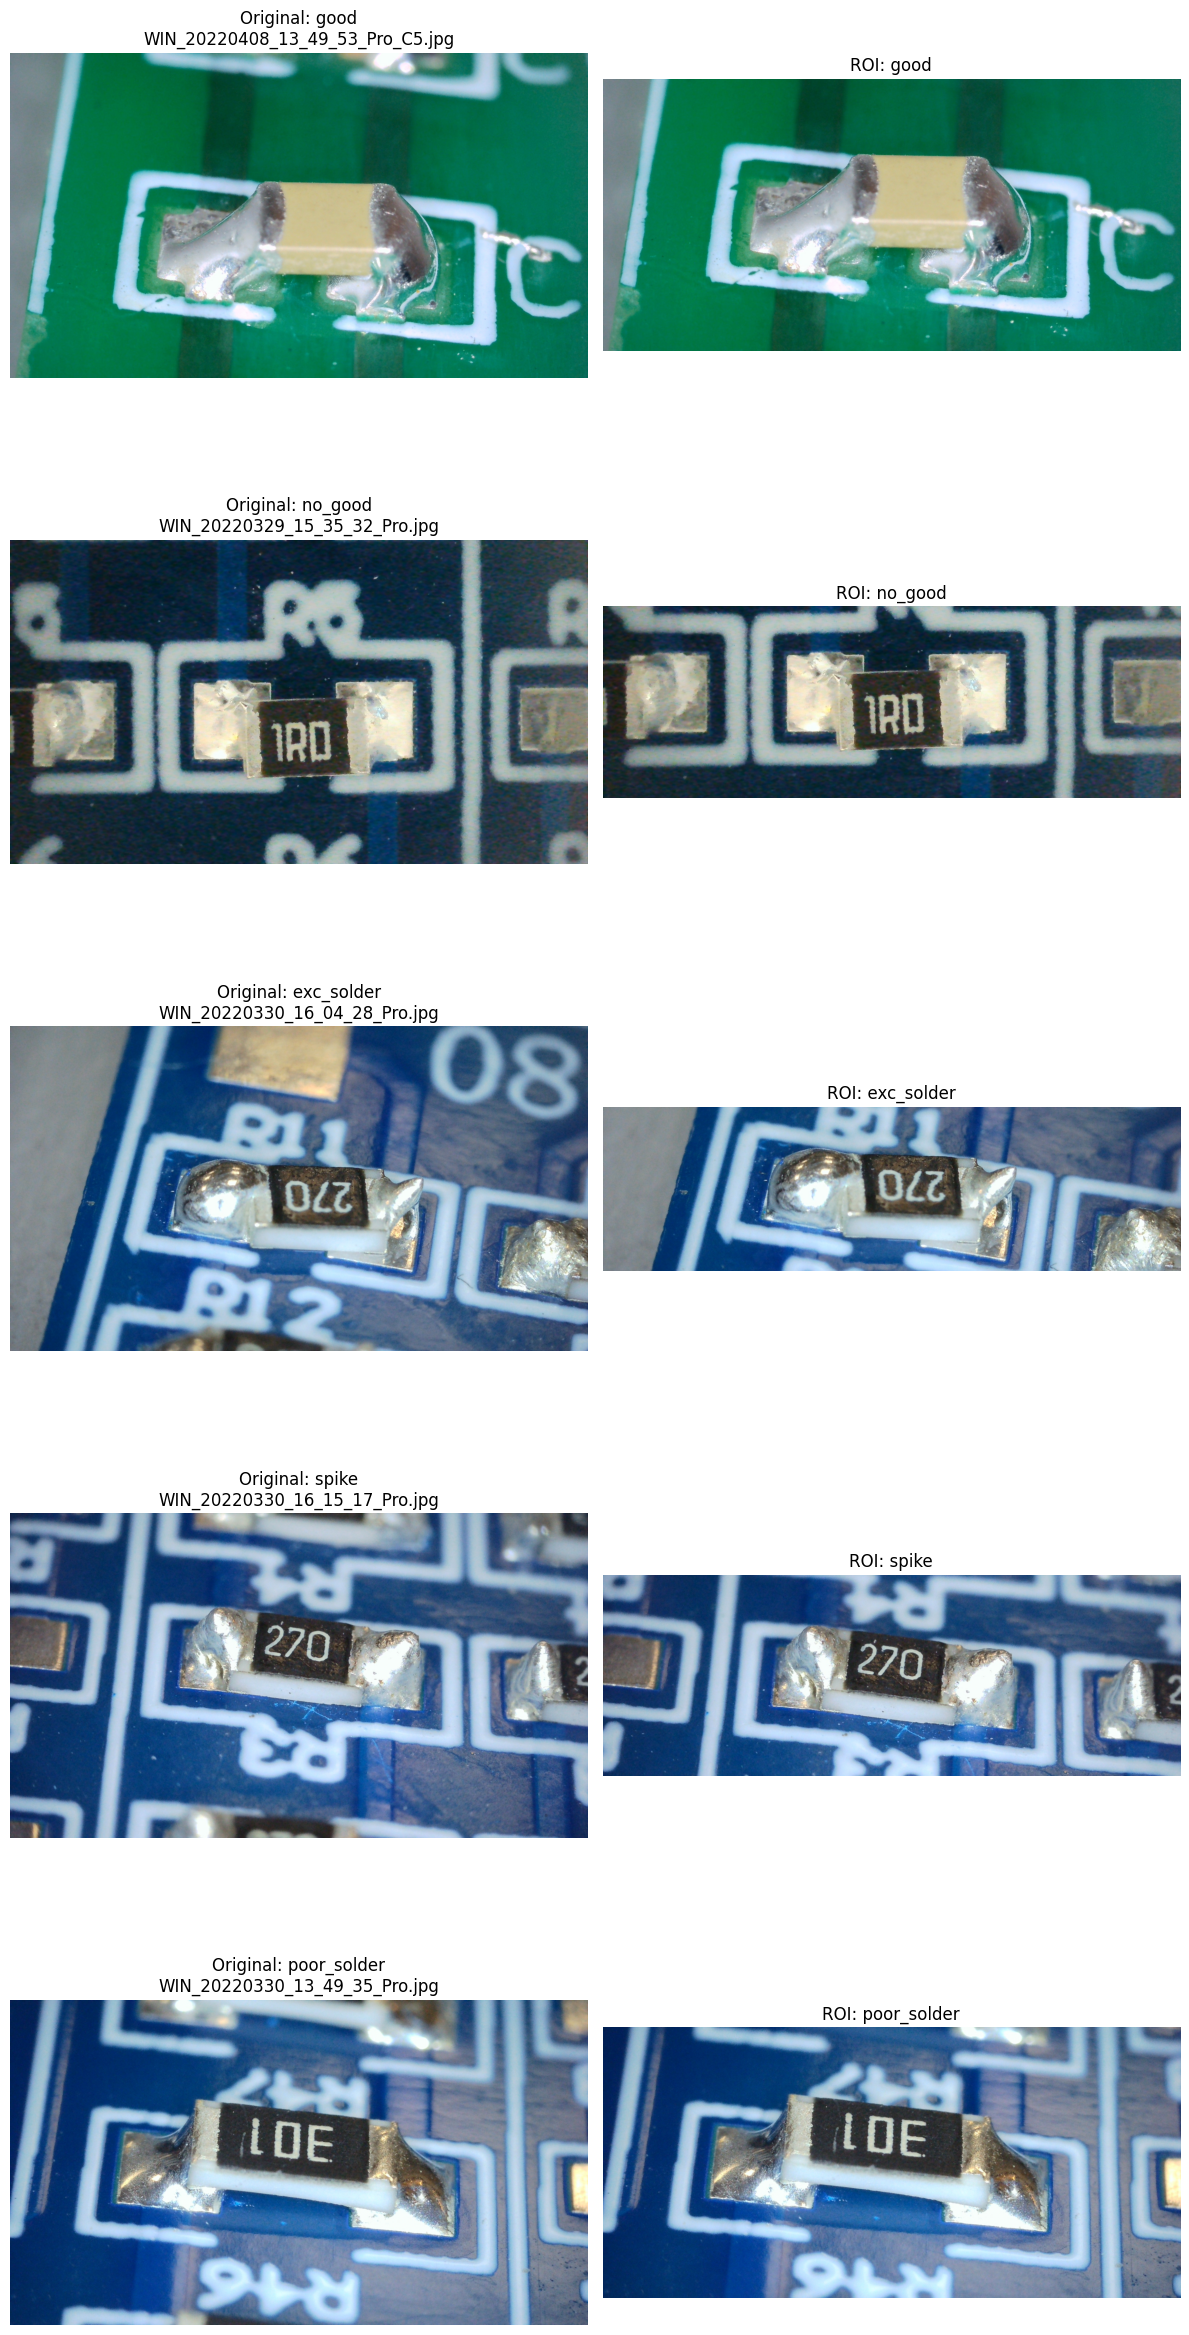

In [40]:
# Define labels in the order we want to display them
label_order = ["good", "no_good", "exc_solder", "spike", "poor_solder"]
num_labels = len(label_order)

# Create a subplot grid with one row per label, 2 columns for original and ROI
fig, axes = plt.subplots(num_labels, 2, figsize=(12, 5 * num_labels))

# Iterate through each label
for idx, label in enumerate(label_order):
    ax_orig = axes[idx, 0]    # Original image axes
    ax_roi = axes[idx, 1]     # ROI image axes
    group = df[df['label'] == label]
    
    if not group.empty:
        # Sample one image from the group
        sample = group.sample(n=1).iloc[0]
        image_path = sample['filename']
        json_path = image_path.replace('.jpg', '.json')
        
        try:
            # Load and display the original image
            image = Image.open(image_path)
            ax_orig.imshow(image)
            ax_orig.set_title(f"Original: {label}\n{os.path.basename(sample['filename'])}")
            ax_orig.axis('off')
            
            # Load and display the ROI
            roi = extract_roi(image_path, json_path)
            ax_roi.imshow(roi)
            ax_roi.set_title(f"ROI: {label}")
            ax_roi.axis('off')
            
        except Exception as e:
            # Display error message if image loading fails
            ax_orig.text(0.5, 0.5, f"Error loading image:\n{e}", ha='center', va='center')
            ax_roi.text(0.5, 0.5, f"Error with ROI:\n{e}", ha='center', va='center')
    else:
        # Display message if no image is found for the label
        ax_orig.text(0.5, 0.5, "No image found", ha='center', va='center')
        ax_roi.text(0.5, 0.5, "No image found", ha='center', va='center')

# Adjust layout and display the plot
plt.tight_layout()
plt.show()

# preprocessing and augmentation

In [31]:
# Preprocessing
df_filtered = df[~df['label'].isin(['good', 'no_good'])].copy()